# Análise Exploratória - Sarampo (SINAN)

Dados de notificação/exames de sarampo e rubéola extraídos do DATASUS (SINAN), ficha EXAN.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CSV_PATH = Path("..") / "data" / "processed" / "sinan_sarampo_exames_2026.csv"

# Paleta categórica validada (blue, orange, aqua, yellow, magenta, green, violet, red)
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQUENTIAL_BLUE = "#2a78d6"
TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT_SECONDARY,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "text.color": TEXT_PRIMARY,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

df = pd.read_csv(CSV_PATH)
df.shape

(873, 107)

## 2. Visão geral

In [2]:
df.head()

,tipo_notificacao,codigo_agravo,suspeita_diagnostica,data_notificacao,semana_epidemiologica_notificacao,ano_notificacao,uf_notificacao,municipio_notificacao,regional_saude_notificacao,unidade_notificadora,...,uf_deslocamento_3,municipio_deslocamento_1,municipio_deslocamento_2,municipio_deslocamento_3,pais_deslocamento_1,pais_deslocamento_2,pais_deslocamento_3,descricao_local_deslocamento_1,descricao_local_deslocamento_2,descricao_local_deslocamento_3
0,2,B09,1,2026-01-05,202601,2026,32,320520,32002.0,2678179,...,NaN,320520.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,2,B09,1,2026-01-06,202601,2026,32,320520,32002.0,2678179,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,B09,1,2026-01-10,202601,2026,32,320530,32002.0,11835,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SEM DE,NaN,NaN
3,2,B09,1,2026-01-13,202602,2026,32,320500,32002.0,2486040,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SEM HI,SEM HI,SEM HI
4,2,B09,2,2026-01-31,202604,2026,32,320240,32002.0,7557523,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 873 entries, 0 to 872
Columns: 107 entries, tipo_notificacao to descricao_local_deslocamento_3
dtypes: float64(72), int64(11), str(24)
memory usage: 729.9 KB


In [4]:
# % de valores ausentes por coluna (top 20 colunas com mais nulos)
(df.isna().mean() * 100).sort_values(ascending=False).head(20)

fluxo_retorno                            100.000000
migrado_sistema_antigo                   100.000000
fluxo_recebido                           100.000000
data_transferencia_regional_municipio    100.000000
data_deslocamento_1                      100.000000
pais_deslocamento_2                      100.000000
uf_deslocamento_3                        100.000000
uf_deslocamento_2                        100.000000
data_deslocamento_3                      100.000000
data_deslocamento_2                      100.000000
pais_deslocamento_3                      100.000000
municipio_deslocamento_2                 100.000000
municipio_deslocamento_3                 100.000000
uf_provavel_infeccao                     100.000000
data_obito                                99.885452
pais_deslocamento_1                       99.885452
uf_deslocamento_1                         99.885452
municipio_deslocamento_1                  99.885452
data_transferencia_municipio              99.770905
descricao_lo

## 3. Distribuição temporal dos casos

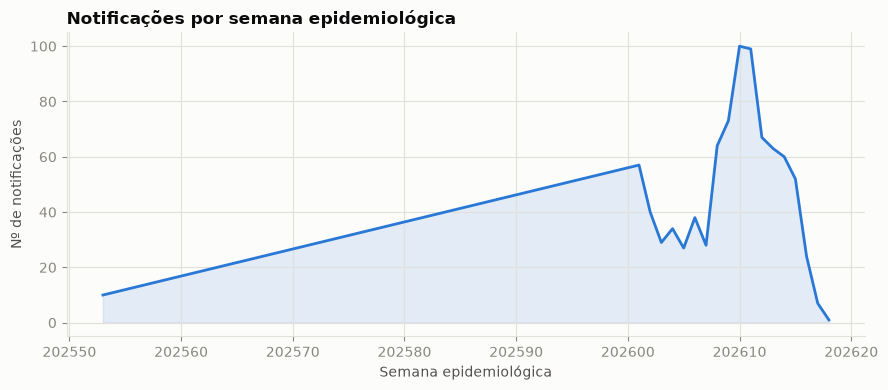

In [5]:
casos_por_semana = (
    df["semana_epidemiologica_notificacao"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(casos_por_semana.index, casos_por_semana.values, color=SEQUENTIAL_BLUE, linewidth=2)
ax.fill_between(casos_por_semana.index, casos_por_semana.values, color=SEQUENTIAL_BLUE, alpha=0.12)
ax.set_title("Notificações por semana epidemiológica", loc="left", fontweight="bold")
ax.set_xlabel("Semana epidemiológica")
ax.set_ylabel("Nº de notificações")
plt.tight_layout()
plt.show()

## 4. Distribuição geográfica (UF de notificação)

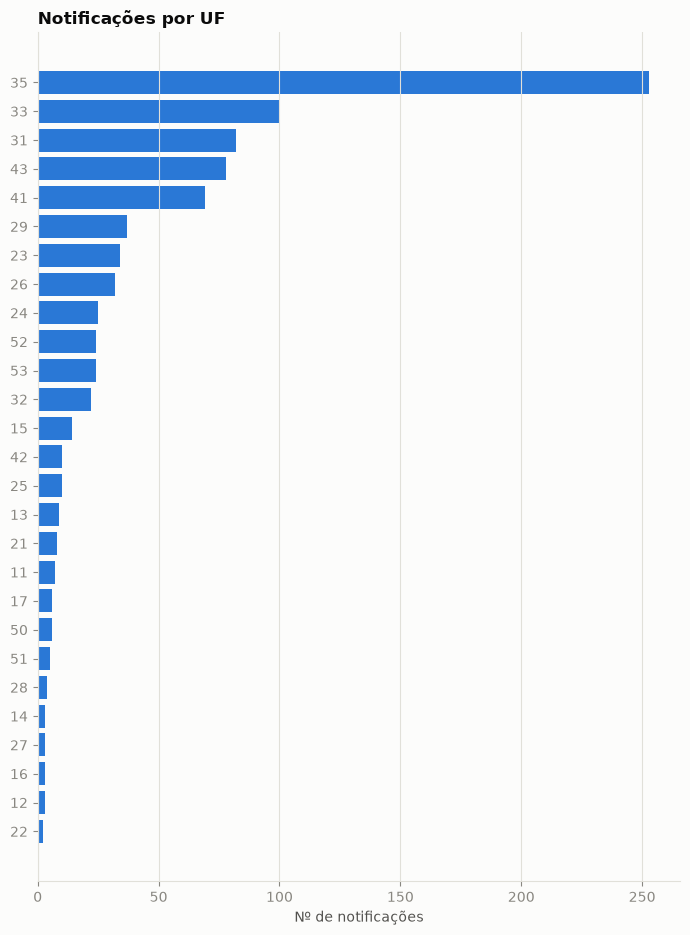

In [6]:
casos_por_uf = df["uf_notificacao"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, max(4, len(casos_por_uf) * 0.35)))
ax.barh(casos_por_uf.index.astype(str), casos_por_uf.values, color=SEQUENTIAL_BLUE)
ax.set_title("Notificações por UF", loc="left", fontweight="bold")
ax.set_xlabel("Nº de notificações")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 5. Perfil demográfico

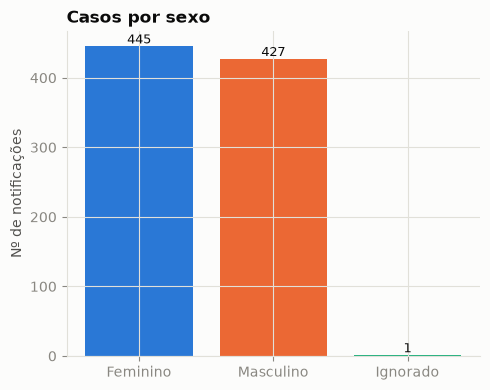

In [7]:
sexo_labels = {"M": "Masculino", "F": "Feminino", "I": "Ignorado"}
casos_por_sexo = df["sexo"].map(sexo_labels).fillna("Ignorado").value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(casos_por_sexo.index, casos_por_sexo.values, color=CATEGORICAL[: len(casos_por_sexo)])
ax.set_title("Casos por sexo", loc="left", fontweight="bold")
ax.set_ylabel("Nº de notificações")
for i, v in enumerate(casos_por_sexo.values):
    ax.text(i, v, str(v), ha="center", va="bottom", color=TEXT_PRIMARY, fontsize=9)
plt.tight_layout()
plt.show()

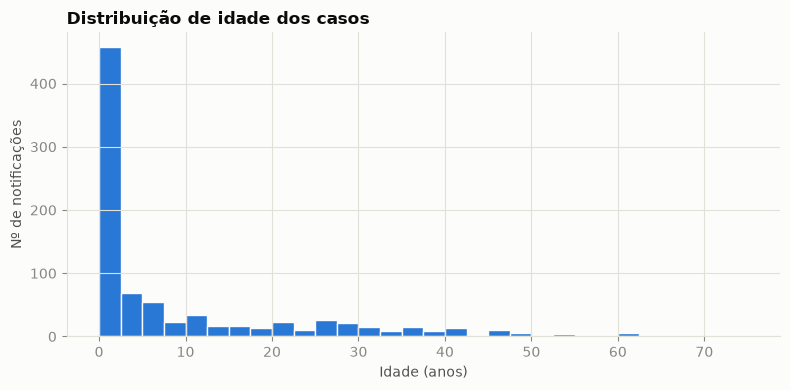

In [8]:
def decodificar_idade(codigo):
    """Decodifica NU_IDADE_N do SINAN (1º dígito = unidade: 1=horas, 2=dias, 3=meses, 4=anos) para idade em anos."""
    if pd.isna(codigo):
        return None
    codigo = str(int(codigo)).zfill(4)
    unidade, valor = codigo[0], int(codigo[1:])
    if unidade == "4":
        return valor
    if unidade == "3":
        return valor / 12
    if unidade in ("1", "2"):
        return 0.0
    return None


df["idade_anos"] = df["idade"].apply(decodificar_idade)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["idade_anos"].dropna(), bins=30, color=SEQUENTIAL_BLUE, edgecolor=SURFACE)
ax.set_title("Distribuição de idade dos casos", loc="left", fontweight="bold")
ax.set_xlabel("Idade (anos)")
ax.set_ylabel("Nº de notificações")
plt.tight_layout()
plt.show()

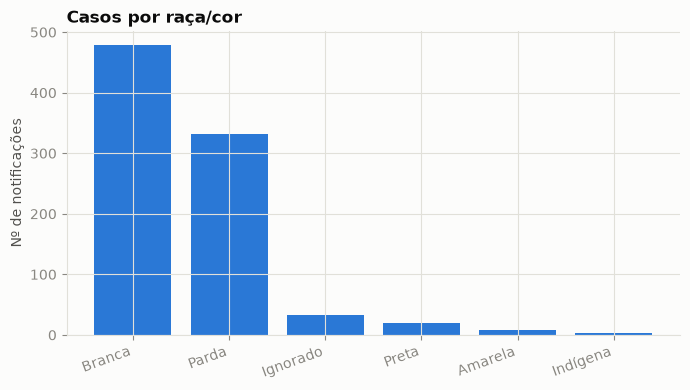

In [9]:
raca_labels = {
    1: "Branca", 2: "Preta", 3: "Amarela", 4: "Parda", 5: "Indígena", 9: "Ignorado",
}
casos_por_raca = df["raca_cor"].map(raca_labels).fillna("Ignorado").value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(casos_por_raca.index, casos_por_raca.values, color=SEQUENTIAL_BLUE)
ax.set_title("Casos por raça/cor", loc="left", fontweight="bold")
ax.set_ylabel("Nº de notificações")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 6. Sinais e sintomas

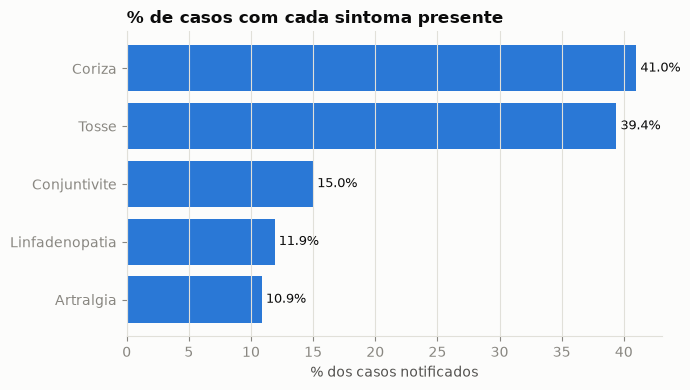

In [10]:
# Campos SINAN: 1 = Sim, 2 = Não, 9 = Ignorado
sintomas = {
    "tosse": "Tosse",
    "coriza": "Coriza",
    "conjuntivite": "Conjuntivite",
    "artralgia": "Artralgia",
    "linfadenopatia": "Linfadenopatia",
}

percentual_sim = {
    label: (df[col] == 1).mean() * 100
    for col, label in sintomas.items()
    if col in df.columns
}
serie = pd.Series(percentual_sim).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(serie.index, serie.values, color=SEQUENTIAL_BLUE)
ax.set_title("% de casos com cada sintoma presente", loc="left", fontweight="bold")
ax.set_xlabel("% dos casos notificados")
ax.grid(axis="y", visible=False)
for i, v in enumerate(serie.values):
    ax.text(v, i, f" {v:.1f}%", va="center", color=TEXT_PRIMARY, fontsize=9)
plt.tight_layout()
plt.show()

## 7. Situação vacinal

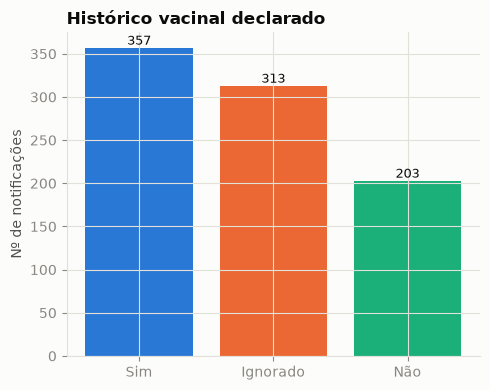

In [11]:
vacina_labels = {1: "Sim", 2: "Não", 9: "Ignorado"}
casos_por_vacina = df["historico_vacinal"].map(vacina_labels).fillna("Ignorado").value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(casos_por_vacina.index, casos_por_vacina.values, color=CATEGORICAL[: len(casos_por_vacina)])
ax.set_title("Histórico vacinal declarado", loc="left", fontweight="bold")
ax.set_ylabel("Nº de notificações")
for i, v in enumerate(casos_por_vacina.values):
    ax.text(i, v, str(v), ha="center", va="bottom", color=TEXT_PRIMARY, fontsize=9)
plt.tight_layout()
plt.show()

## 8. Classificação final e desfecho

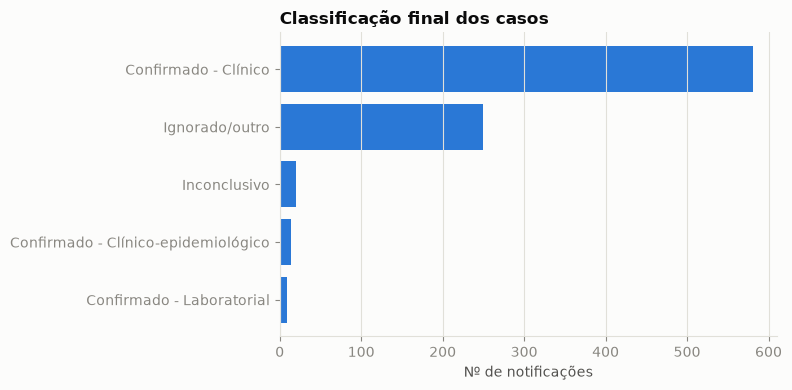

In [12]:
classi_fin_labels = {
    1: "Confirmado - Laboratorial",
    2: "Confirmado - Clínico-epidemiológico",
    3: "Confirmado - Clínico",
    4: "Confirmado - Vínculo epidemiológico",
    5: "Descartado",
    8: "Inconclusivo",
}
casos_por_classi = df["classificacao_final"].map(classi_fin_labels).fillna("Ignorado/outro").value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(casos_por_classi.index[::-1], casos_por_classi.values[::-1], color=SEQUENTIAL_BLUE)
ax.set_title("Classificação final dos casos", loc="left", fontweight="bold")
ax.set_xlabel("Nº de notificações")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

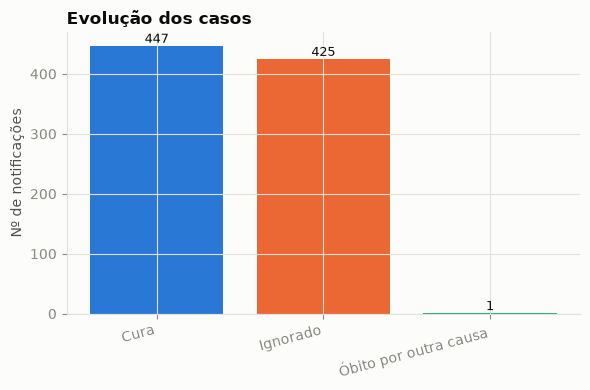

In [13]:
evolucao_labels = {1: "Cura", 2: "Óbito pelo agravo", 3: "Óbito por outra causa", 9: "Ignorado"}
casos_por_evolucao = df["evolucao_caso"].map(evolucao_labels).fillna("Ignorado").value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(casos_por_evolucao.index, casos_por_evolucao.values, color=CATEGORICAL[: len(casos_por_evolucao)])
ax.set_title("Evolução dos casos", loc="left", fontweight="bold")
ax.set_ylabel("Nº de notificações")
plt.xticks(rotation=15, ha="right")
for i, v in enumerate(casos_por_evolucao.values):
    ax.text(i, v, str(v), ha="center", va="bottom", color=TEXT_PRIMARY, fontsize=9)
plt.tight_layout()
plt.show()

## 9. Cruzamento: faixa etária x classificação final

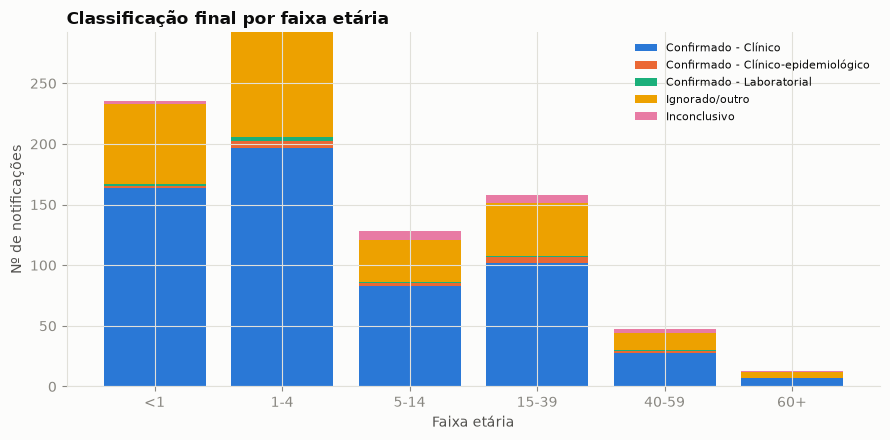

In [14]:
faixas = [0, 1, 5, 15, 40, 60, 120]
rotulos_faixas = ["<1", "1-4", "5-14", "15-39", "40-59", "60+"]
df["faixa_etaria"] = pd.cut(df["idade_anos"], bins=faixas, labels=rotulos_faixas, right=False)

df["classificacao_final_label"] = df["classificacao_final"].map(classi_fin_labels).fillna("Ignorado/outro")

tabela = pd.crosstab(df["faixa_etaria"], df["classificacao_final_label"])

fig, ax = plt.subplots(figsize=(9, 4.5))
bottom = None
for i, coluna in enumerate(tabela.columns):
    valores = tabela[coluna].values
    ax.bar(tabela.index.astype(str), valores, bottom=bottom, label=coluna, color=CATEGORICAL[i % len(CATEGORICAL)])
    bottom = valores if bottom is None else bottom + valores
ax.set_title("Classificação final por faixa etária", loc="left", fontweight="bold")
ax.set_xlabel("Faixa etária")
ax.set_ylabel("Nº de notificações")
ax.legend(frameon=False, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()